# Joint optimization of grating coupler geometry and Gaussian beam parameters

Grating couplers are commonly used to couple light between an optical fiber or free space beam and an on chip waveguide. For background on grating coupler modeling in Tidy3D, see the [uniform grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/) example and the [focused apodized grating coupler](https://www.flexcompute.com/tidy3d/examples/notebooks/FocusedApodGC/) example. For a closely related optimization workflow, the [inverse design of a grating coupler with the adjoint method](https://www.flexcompute.com/tidy3d/examples/notebooks/AdjointPlugin6GratingCoupler/) shows how gradients can be used to improve grating coupler performance with a freeform design region.

When modeling coupling from a fiber or free space source, we often represent the incoming light with a Gaussian beam profile. This beam has its own center position, angular tilt, and waist radius. The coupling performance therefore depends not only on the grating geometry, but also on how the Gaussian beam is placed above the device. A source position, tilt angle, or waist that works well for one grating can be suboptimal after the grating geometry changes during optimization, so it may be less effective to optimize the grating first and tune the source afterward, or to fix the source first and optimize only the grating.

<p align="center">
  <img src="img/grating_coupler_beam_optimization_thumbnail.png" width="650" alt="Schematic of a grating coupler and Gaussian beam source">
</p>

This notebook demonstrates a joint approach: instead of prescribing the beam settings ahead of time, we include them directly in the design variables for a simple 1D grating coupler. Tidy3D Autograd computes gradients with respect to both the grating dimensions and the Gaussian beam parameters, allowing the optimizer to reshape the grating and reposition the beam in a single optimization loop.

We show two related inverse design problems. First, we optimize a partially etched grating coupler together with the Gaussian beam center position, incident angle, and waist. Second, we add a lower silicon reflector grating separated from the top grating by a silicon dioxide gap. The reflector is parameterized by a single period and duty cycle, while the top grating and Gaussian beam parameters are again optimized. Both objectives maximize coupling into the backward propagating waveguide mode.

In [1]:
import autograd.numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d.components.autograd.utils import get_static
from tidy3d.plugins.autograd import adam, optimize
from tidy3d.web import run

np.set_printoptions(precision=4, suppress=True)

## Problem Setup

We work with a compact 2D grating coupler model. The top grating uses individual tooth and trench widths as design variables. The Gaussian beam source is also part of the optimization through three parameters:

- lateral source position `x_center`,
- source tilt angle `tilt`,
- beam waist `waist`.

The second design adds a lower silicon reflector grating. To keep this reflector easy to interpret, it uses a global period and duty cycle rather than independent widths for every reflector tooth.

In [2]:
# Center wavelength and frequency for the single frequency coupling objective.
wavelength = 1.55
freq = td.C_0 / wavelength

# Top silicon grating parameters for the compact 2D model.
min_feature_size = 0.100
n_periods = 20
h_si = 0.220
n_si = 3.48

# Gaussian beam source initialization and bounds.
source_z = 2.0
initial_tilt = np.radians(8.0)
initial_waist = 2.25
waist_bounds = (2.0, 2.5)

# Lower reflector geometry. The top of the reflector is this far below the
# bottom of the top grating layer, so the gap represents silicon dioxide.
reflector_gap = 0.400
reflector_thickness = h_si
n_reflector_periods = 40

# Bounds for the normalized optimizer variables.
single_layer_bounds = {
    "teeth": (min_feature_size, 1.0),
    "trenches": (min_feature_size, 1.0),
    "x_center": (0.0, 10.0),
    "tilt": (np.radians(0.0), np.radians(20.0)),
    "waist": waist_bounds,
}

reflector_bounds = {
    **single_layer_bounds,
    "reflector_period": (0.20, 0.45),
    "reflector_duty_cycle": (0.20, 0.80),
}

## Parameter And Design Helpers

These helper functions convert between normalized optimizer variables and physical simulation parameters. The normalized representation lets the optimizer work in a unit box, while the physical representation is used to construct Tidy3D geometry and sources.

In [3]:
def to_norm(value_phys, min_val, max_val):
    """Map a physical scalar or array into the optimizer unit interval."""
    return (value_phys - min_val) / (max_val - min_val)


def to_phys(params_norm, bounds):
    """Map normalized optimizer parameters back to physical units."""
    return {
        key: bounds[key][0] + value * (bounds[key][1] - bounds[key][0])
        for key, value in params_norm.items()
    }


def physical_to_normalized(params_phys, bounds):
    """Normalize a dictionary of physical parameters using matching bounds."""
    return {
        key: to_norm(value, bounds[key][0], bounds[key][1]) for key, value in params_phys.items()
    }


def calculate_initial_widths(wavelength, tilt_angle_rad, n_clad=1.0):
    """Return a simple Bragg style starting tooth and trench width."""
    n_slab = 2.85
    n_etch = 2.25
    n_eff_grating = 0.5 * n_slab + 0.5 * n_etch
    period = wavelength / (n_eff_grating - n_clad * np.sin(tilt_angle_rad))
    return period / 2.0, period / 2.0


def make_initial_design_phys(include_reflector=False):
    """Construct the physical starting point for either optimization branch."""
    init_tooth, init_trench = calculate_initial_widths(wavelength, initial_tilt, n_clad=1.0)
    params = {
        "teeth": np.ones(n_periods) * init_tooth,
        "trenches": np.ones(n_periods) * init_trench,
        "x_center": 6.0,
        "tilt": initial_tilt,
        "waist": initial_waist,
    }
    if include_reflector:
        params["reflector_period"] = 0.32
        params["reflector_duty_cycle"] = 0.50
    return params


def compute_grating_edges(params_phys):
    """Compute top grating tooth start and end positions."""
    teeth = np.asarray(params_phys["teeth"], dtype=float)
    trenches = np.asarray(params_phys["trenches"], dtype=float)
    periods = teeth + trenches
    starts = np.cumsum(np.concatenate([[0.0], periods[:-1]]))
    ends = starts + teeth
    return starts, ends

## Simulation And Figure Of Merit

The simulation builder creates the top grating coupler, the Gaussian beam source, and optionally the lower silicon reflector grating. The reflector sits below the top grating across the grating region and is intended to scatter downward radiation back toward the waveguide, improving useful unidirectional coupling.

In [4]:
def make_top_grating_structures(params_phys):
    teeth = np.array(params_phys["teeth"])
    trenches = np.array(params_phys["trenches"])
    periods = teeth + trenches
    starts = np.cumsum(np.concatenate([[0.0], periods[:-1]]))

    structures = [
        td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(-10000, -10000, -0.5 * h_si),
                rmax=(0, 10000, 0.5 * h_si),
            ),
            medium=td.Medium(permittivity=n_si**2),
        )
    ]

    grating_geometry = 0
    for start, tooth_width in zip(starts, teeth):
        center_x = start + tooth_width / 2.0
        grating_geometry += td.Box(
            center=(center_x, 0, 0.25 * h_si),
            size=(tooth_width, td.inf, 0.5 * h_si),
        )

    structures.append(
        td.Structure(geometry=grating_geometry, medium=td.Medium(permittivity=n_si**2))
    )

    structure_start_x = starts[0]
    structure_end_x = starts[-1] + teeth[-1]
    structures.append(
        td.Structure(
            geometry=td.Box.from_bounds(
                rmin=(structure_start_x, -10000, -0.5 * h_si),
                rmax=(structure_end_x, 10000, 0.0),
            ),
            medium=td.Medium(permittivity=n_si**2),
        )
    )
    return structures, structure_end_x


def make_reflector_structure(params_phys):
    """Build the lower silicon reflector from a global period and duty cycle.

    The reflector is a repeated silicon grating located below the top device
    layer. It is deliberately lower dimensional than the top grating: the
    optimizer controls only one period and one duty cycle, which are repeated
    across enough periods to cover the top grating region.
    """
    period = params_phys["reflector_period"]
    duty_cycle = params_phys["reflector_duty_cycle"]
    tooth_width = period * duty_cycle
    starts = np.arange(n_reflector_periods) * period

    reflector_top_z = -0.5 * h_si - reflector_gap
    reflector_center_z = reflector_top_z - 0.5 * reflector_thickness
    reflector_geometry = 0
    for start in starts:
        reflector_geometry += td.Box(
            center=(start + tooth_width / 2.0, 0, reflector_center_z),
            size=(tooth_width, td.inf, reflector_thickness),
        )
    reflector_end_x = n_reflector_periods * period
    return td.Structure(
        geometry=reflector_geometry, medium=td.Medium(permittivity=n_si**2)
    ), reflector_end_x


def build_2d_sim(params_phys, include_reflector=False, include_field_monitor=False):
    """Construct the Tidy3D simulation for one set of physical parameters.

    Parameters in ``params_phys`` define both the geometry and the Gaussian
    beam source. Setting ``include_reflector=True`` appends the lower reflector
    grating to the single-layer grating coupler. The field monitor is omitted
    during optimization to keep the simulations lighter and added only for the
    final visualization runs.
    """
    structures, structure_end_x = make_top_grating_structures(params_phys)

    if include_reflector:
        reflector_structure, reflector_end_x = make_reflector_structure(params_phys)
        structures.append(reflector_structure)
        sim_end_x = get_static(np.maximum(structure_end_x, reflector_end_x) + 1.5)
    else:
        sim_end_x = get_static(structure_end_x + 1.5)

    sim_start_x = -10.0
    sim_center = (0.5 * (sim_start_x + sim_end_x), 0, 0)
    sim_size = (sim_end_x - sim_start_x, 0, 7.0)

    source = td.GaussianBeam(
        center=(params_phys["x_center"], 0, source_z),
        size=(td.inf, td.inf, 0),
        source_time=td.GaussianPulse(freq0=freq, fwidth=freq / 10),
        direction="-",
        angle_theta=params_phys["tilt"],
        waist_radius=params_phys["waist"],
        pol_angle=np.pi / 2,
    )

    monitor = td.ModeMonitor(
        center=(-2.0, 0, 0),
        size=(0, td.inf, h_si * 5),
        freqs=[freq],
        mode_spec=td.ModeSpec(num_modes=1),
        name="mode_mnt",
    )
    monitors = [monitor]

    if include_field_monitor:
        monitors.append(
            td.FieldMonitor(
                center=sim_center,
                size=sim_size,
                freqs=[freq],
                name="field_mnt",
            )
        )

    return td.Simulation(
        center=sim_center,
        size=sim_size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=15),
        structures=structures,
        sources=[source],
        monitors=monitors,
        run_time=2e-11,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.periodic(),
            z=td.Boundary.pml(),
        ),
    )


def coupling_efficiency_from_sim(params_phys, task_name, include_reflector=False, as_float=False):
    """Evaluate the differentiable coupling efficiency objective.

    The figure of merit is the power coupled into the backward-propagating
    waveguide mode measured by ``mode_mnt``. During optimization we return the
    value that Autograd can differentiate; for reporting cells, ``as_float=True``
    converts it to a plain Python number.
    """
    sim = build_2d_sim(params_phys, include_reflector=include_reflector)
    sim_data = run(sim, task_name=task_name, verbose=False)
    amp = sim_data["mode_mnt"].amps.sel(direction="-").data
    ce = np.sum(np.abs(amp) ** 2)
    return float(np.asarray(ce)) if as_float else ce


def field_data_from_sim(params_phys, task_name, include_reflector=False):
    """Run one simulation with an x-z field monitor for visualization."""
    sim = build_2d_sim(
        params_phys,
        include_reflector=include_reflector,
        include_field_monitor=True,
    )
    return run(sim, task_name=task_name, verbose=False)

## Optimization Driver

Both branches use the same optimization helper. The objective is differentiated with Tidy3D Autograd, and Tidy3D's Adam optimizer updates the normalized design parameters.

In [5]:
def format_progress_line(step, epochs, value, grad_norm):
    return f"step {step:02d}/{epochs:02d} | objective = {value:.6f} | grad norm = {grad_norm:.3e}"


def gradient_l2_norm(gradient):
    """Compute the L2 norm of the flat gradient dictionary used here."""
    squared_norm = sum(np.sum(np.abs(np.asarray(value)) ** 2) for value in gradient.values())
    return float(np.sqrt(squared_norm))


def optimize_params(initial_params_norm, objective_fn, epochs, learning_rate, label, print_every=5):
    """Maximize an objective over normalized parameters with Tidy3D Adam.

    The optimizer works in normalized coordinates bounded between 0 and 1.
    Each objective maps those normalized values back to physical dimensions
    before building the simulation. The returned history stores both the
    objective value and the gradient norm for plotting.
    """
    optimizer = adam(learning_rate=learning_rate)
    params0 = {key: np.array(value, copy=True) for key, value in initial_params_norm.items()}
    grad_norm_history = []

    print(f"\n{label}")
    print(f"{'=' * len(label)}")
    print(f"epochs = {epochs}, learning_rate = {learning_rate:.4f}")

    def print_step(_params, gradient, _state, step_index, objective_value):
        step = step_index + 1
        grad_norm = gradient_l2_norm(gradient)
        grad_norm_history.append(grad_norm)
        should_print = step == 1 or step == epochs or step % print_every == 0
        if should_print:
            value_float = float(np.asarray(objective_value))
            print(format_progress_line(step, epochs, value_float, grad_norm))

    params_norm, _, opt_history = optimize(
        objective_fn,
        params0=params0,
        optimizer=optimizer,
        num_steps=epochs,
        bounds=(0.0, 1.0),
        callback=print_step,
        direction="max",
    )
    history = {
        "objective": [float(np.asarray(value)) for value in opt_history["objective_fn_val"]],
        "grad_norm": grad_norm_history,
    }
    return params_norm, history

## Plotting Helpers

These helpers only format cross sections and summary plots. They can be skimmed or skipped if you want to focus on the simulation setup and optimization code.

In [6]:
plt.rc("figure", facecolor="white")
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

design_labels = {
    "single": "Single layer",
    "reflector": "With reflector",
}
design_colors = {
    "single": "black",
    "reflector": "tab:red",
}
design_markers = {
    "single": "o",
    "reflector": "s",
}


def plot_design_cross_section(params_phys, ax, color, title, include_reflector=False):
    starts, ends = compute_grating_edges(params_phys)
    structure_start_x = float(starts[0])
    structure_end_x = float(ends[-1])
    left_limit = min(-5.0, structure_start_x - 0.5)
    right_limit = structure_end_x + 0.5

    ax.add_patch(
        plt.Rectangle(
            (left_limit, -0.5 * h_si),
            -left_limit,
            h_si,
            facecolor=(0.83, 0.83, 0.83),
            edgecolor="black",
            linewidth=1.0,
            alpha=0.8,
        )
    )
    ax.add_patch(
        plt.Rectangle(
            (structure_start_x, -0.5 * h_si),
            structure_end_x - structure_start_x,
            0.5 * h_si,
            facecolor=color,
            edgecolor="black",
            linewidth=1.0,
            alpha=0.25,
        )
    )
    for x_start, x_end in zip(starts, ends):
        ax.add_patch(
            plt.Rectangle(
                (float(x_start), 0.0),
                float(x_end - x_start),
                0.5 * h_si,
                facecolor=color,
                edgecolor="black",
                linewidth=1.0,
                alpha=0.85,
            )
        )

    if include_reflector:
        period = float(params_phys["reflector_period"])
        duty_cycle = float(params_phys["reflector_duty_cycle"])
        tooth_width = period * duty_cycle
        reflector_top_z = -0.5 * h_si - reflector_gap
        reflector_bottom_z = reflector_top_z - reflector_thickness
        for start in np.arange(n_reflector_periods) * period:
            if start > right_limit:
                break
            ax.add_patch(
                plt.Rectangle(
                    (float(start), reflector_bottom_z),
                    tooth_width,
                    reflector_thickness,
                    facecolor="tab:orange",
                    edgecolor="black",
                    linewidth=0.8,
                    alpha=0.8,
                )
            )

    ax.axvline(float(params_phys["x_center"]), color="black", linestyle="--", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("x [um]")
    ax.set_ylabel("z [um]")
    ax.set_xlim(left_limit, right_limit)
    ax.set_ylim(-1.05, 0.75 * h_si)
    ax.set_aspect("equal")


def plot_history(ax, history, title):
    objective_history = history["objective"]
    grad_norm_history = history["grad_norm"]

    steps = np.arange(1, len(objective_history) + 1)
    objective_line = ax.plot(
        steps, objective_history, color="black", linewidth=2, label="Objective"
    )
    ax.set_title(title)
    ax.set_xlabel("Optimization step")
    ax.set_ylabel("Objective")
    ax.tick_params(axis="y", labelcolor="black")

    grad_steps = np.arange(1, len(grad_norm_history) + 1)
    ax_grad = ax.twinx()
    grad_line = ax_grad.plot(
        grad_steps,
        grad_norm_history,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        label="Gradient norm",
    )
    ax_grad.set_ylabel("Gradient norm", color="tab:orange")
    ax_grad.tick_params(axis="y", labelcolor="tab:orange")
    lines = objective_line + grad_line
    ax.legend(lines, [line.get_label() for line in lines], loc="best")


def plot_width_comparison(design_params, title="Optimized top grating widths"):
    fig, ax = plt.subplots(figsize=(12, 3.8), constrained_layout=True)
    period_indices = np.arange(1, n_periods + 1)
    for design_key, params_phys in design_params.items():
        color = design_colors[design_key]
        ax.plot(
            period_indices,
            params_phys["teeth"],
            color=color,
            linewidth=2,
            marker=design_markers[design_key],
            label=f"{design_labels[design_key]} teeth",
        )
        ax.plot(
            period_indices,
            params_phys["trenches"],
            color=color,
            linewidth=2,
            linestyle="--",
            marker=design_markers[design_key],
            markerfacecolor="white",
            label=f"{design_labels[design_key]} gaps",
        )
    ax.set_title(title)
    ax.set_xlabel("Grating period index")
    ax.set_ylabel("Width [um]")
    ax.set_xticks(period_indices)
    ax.legend(ncol=2, fontsize="small")
    return fig


def plot_field_cross_sections(field_data_by_design):
    fig, axes = plt.subplots(
        len(field_data_by_design),
        1,
        figsize=(12, 4.0 * len(field_data_by_design)),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes)
    for ax, (design_key, sim_data) in zip(axes, field_data_by_design.items()):
        sim_data.plot_field(
            field_monitor_name="field_mnt",
            field_name="E",
            val="abs",
            ax=ax,
        )
        ax.set_title(f"{design_labels[design_key]} field magnitude")
        ax.set_aspect("auto")
    return fig

## Start From A Uniform Seed Design

We begin from a uniform top grating generated from a simple Bragg style estimate. This seed also sets the initial Gaussian beam position, tilt, and waist.

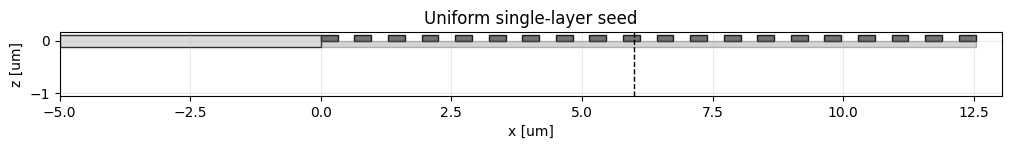

Initial x_center = 6.000 um
Initial tilt = 8.000 deg
Initial waist = 2.250 um


In [7]:
initial_single_phys = make_initial_design_phys(include_reflector=False)
initial_reflector_phys = make_initial_design_phys(include_reflector=True)

fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
plot_design_cross_section(
    initial_single_phys, ax=ax, color="0.35", title="Uniform single-layer seed"
)
plt.show()

print(f"Initial x_center = {initial_single_phys['x_center']:.3f} um")
print(f"Initial tilt = {np.degrees(initial_single_phys['tilt']):.3f} deg")
print(f"Initial waist = {initial_single_phys['waist']:.3f} um")

## Stage 1: Single-Layer Grating And Beam Optimization

The first optimization updates the top grating geometry together with the Gaussian beam source parameters. This demonstrates how to include source position, source tilt, and source waist directly in a Tidy3D Autograd optimization.

In [8]:
def objective_single(params_norm):
    params_phys = to_phys(params_norm, single_layer_bounds)
    return coupling_efficiency_from_sim(
        params_phys,
        task_name="grating_beam_single",
        include_reflector=False,
    )


optimization_epochs = 90
learning_rate = 0.003
print_every = 5

single_initial_norm = physical_to_normalized(initial_single_phys, single_layer_bounds)
single_norm, single_history = optimize_params(
    single_initial_norm,
    objective_fn=objective_single,
    epochs=optimization_epochs,
    learning_rate=learning_rate,
    label="Single-layer grating and beam optimization",
    print_every=print_every,
)
single_design_phys = to_phys(single_norm, single_layer_bounds)


Single-layer grating and beam optimization
epochs = 90, learning_rate = 0.0030
step 01/90 | objective = 0.084270 | grad norm = 1.229e+00
step 05/90 | objective = 0.140750 | grad norm = 6.235e-01
step 10/90 | objective = 0.145501 | grad norm = 1.005e+00
step 15/90 | objective = 0.165367 | grad norm = 8.510e-01
step 20/90 | objective = 0.176042 | grad norm = 1.053e+00
step 25/90 | objective = 0.199274 | grad norm = 6.669e-01
step 30/90 | objective = 0.214997 | grad norm = 7.155e-01
step 35/90 | objective = 0.234634 | grad norm = 8.797e-01
step 40/90 | objective = 0.253888 | grad norm = 7.545e-01
step 45/90 | objective = 0.274034 | grad norm = 9.434e-01
step 50/90 | objective = 0.288923 | grad norm = 1.119e+00
step 55/90 | objective = 0.307696 | grad norm = 8.266e-01
step 60/90 | objective = 0.317485 | grad norm = 1.209e+00
step 65/90 | objective = 0.329971 | grad norm = 4.592e-01
step 70/90 | objective = 0.334242 | grad norm = 9.036e-01
step 75/90 | objective = 0.342667 | grad norm = 7.

### Single-Layer Result

After the first optimization, we evaluate the optimized design at the nominal source condition and plot both the final cross section and the optimization history. The printed source parameters show how the Gaussian beam moved during the optimization.

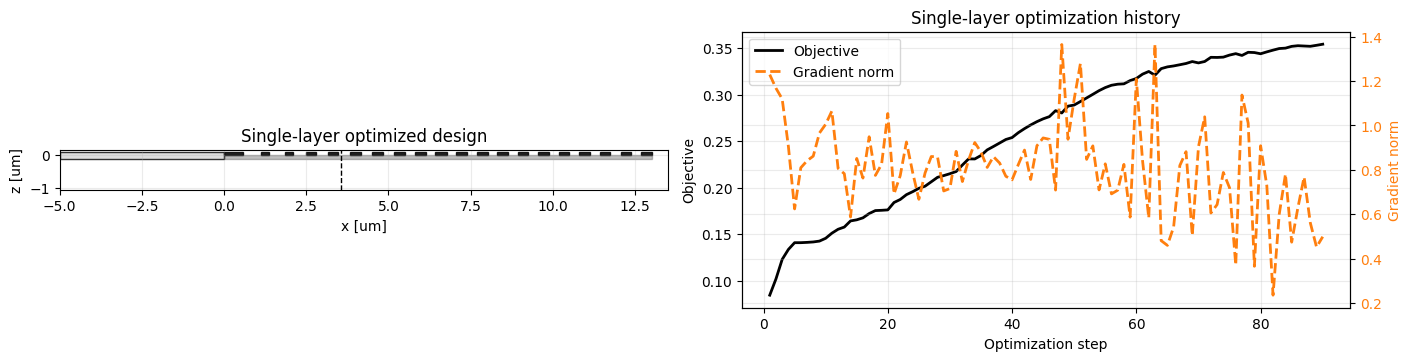

Single-layer nominal CE = 0.352976
Single-layer x_center = 3.569 um
Single-layer tilt = 9.690 deg
Single-layer waist = 2.379 um


In [9]:
single_nominal_ce = coupling_efficiency_from_sim(
    single_design_phys,
    task_name="grating_beam_single_nominal_final",
    include_reflector=False,
    as_float=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)
plot_design_cross_section(
    single_design_phys,
    ax=axes[0],
    color=design_colors["single"],
    title="Single-layer optimized design",
)
plot_history(axes[1], single_history, "Single-layer optimization history")
plt.show()

print(f"Single-layer nominal CE = {single_nominal_ce:.6f}")
print(f"Single-layer x_center = {single_design_phys['x_center']:.3f} um")
print(f"Single-layer tilt = {np.degrees(single_design_phys['tilt']):.3f} deg")
print(f"Single-layer waist = {single_design_phys['waist']:.3f} um")

## Stage 2: Add A Lower Reflector Grating

The second optimization adds a silicon reflector grating below the top grating, separated by a 400 nm silicon dioxide gap. The reflector is intentionally simple: it uses one global period and one global duty cycle, repeated enough times to cover the top grating region. This lower grating is optimized together with the top grating geometry and Gaussian beam parameters.

In [12]:
def objective_reflector(params_norm):
    params_phys = to_phys(params_norm, reflector_bounds)
    return coupling_efficiency_from_sim(
        params_phys,
        task_name="grating_beam_reflector",
        include_reflector=True,
    )


optimization_epochs = 90
learning_rate = 0.003
print_every = 5

reflector_initial_norm = physical_to_normalized(initial_reflector_phys, reflector_bounds)
reflector_norm, reflector_history = optimize_params(
    reflector_initial_norm,
    objective_fn=objective_reflector,
    epochs=optimization_epochs,
    learning_rate=learning_rate,
    label="Reflector grating and beam optimization",
    print_every=print_every,
)
reflector_design_phys = to_phys(reflector_norm, reflector_bounds)


Reflector grating and beam optimization
epochs = 90, learning_rate = 0.0030
step 01/90 | objective = 0.198748 | grad norm = 2.288e+00
step 05/90 | objective = 0.280728 | grad norm = 1.845e+00
step 10/90 | objective = 0.308899 | grad norm = 1.517e+00
step 15/90 | objective = 0.345474 | grad norm = 2.142e+00
step 20/90 | objective = 0.377360 | grad norm = 2.077e+00
step 25/90 | objective = 0.418240 | grad norm = 1.794e+00
step 30/90 | objective = 0.451548 | grad norm = 1.873e+00
step 35/90 | objective = 0.475962 | grad norm = 4.308e+00
step 40/90 | objective = 0.517014 | grad norm = 2.262e+00
step 45/90 | objective = 0.549722 | grad norm = 2.061e+00
step 50/90 | objective = 0.582705 | grad norm = 1.334e+00
step 55/90 | objective = 0.609034 | grad norm = 1.604e+00
step 60/90 | objective = 0.624934 | grad norm = 1.807e+00
step 65/90 | objective = 0.630303 | grad norm = 3.563e+00
step 70/90 | objective = 0.660135 | grad norm = 1.067e+00
step 75/90 | objective = 0.668581 | grad norm = 1.005

### Reflector Result

We now evaluate the two-layer design at the nominal source condition. The summary includes the optimized Gaussian beam parameters as well as the reflector period and duty cycle, which are the two additional design variables introduced in this stage.

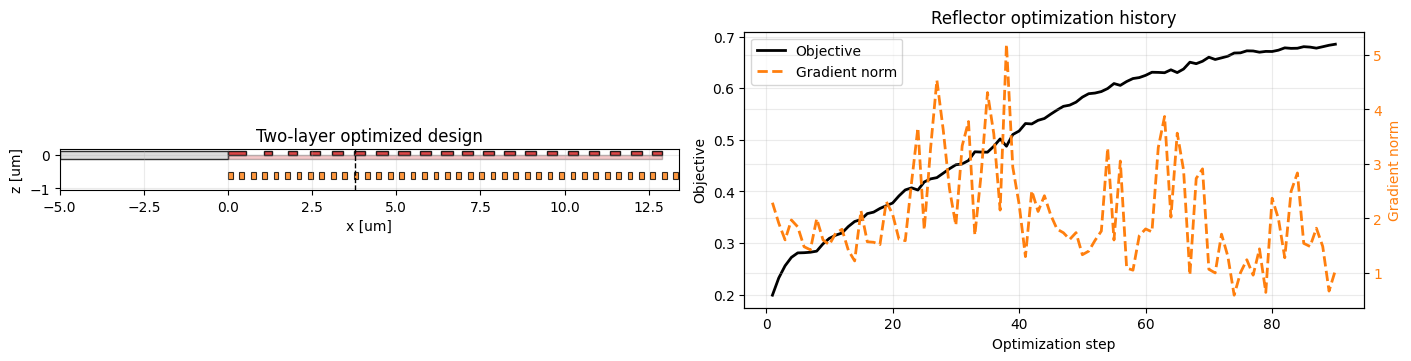

Reflector nominal CE = 0.685303
Reflector x_center = 3.762 um
Reflector tilt = 9.858 deg
Reflector waist = 2.373 um
Reflector period = 0.339 um
Reflector duty cycle = 0.417


In [13]:
reflector_nominal_ce = coupling_efficiency_from_sim(
    reflector_design_phys,
    task_name="grating_beam_reflector_nominal_final",
    include_reflector=True,
    as_float=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)
plot_design_cross_section(
    reflector_design_phys,
    ax=axes[0],
    color=design_colors["reflector"],
    title="Two-layer optimized design",
    include_reflector=True,
)
plot_history(axes[1], reflector_history, "Reflector optimization history")
plt.show()

print(f"Reflector nominal CE = {reflector_nominal_ce:.6f}")
print(f"Reflector x_center = {reflector_design_phys['x_center']:.3f} um")
print(f"Reflector tilt = {np.degrees(reflector_design_phys['tilt']):.3f} deg")
print(f"Reflector waist = {reflector_design_phys['waist']:.3f} um")
print(f"Reflector period = {reflector_design_phys['reflector_period']:.3f} um")
print(f"Reflector duty cycle = {reflector_design_phys['reflector_duty_cycle']:.3f}")

## Final Comparison

We finish by comparing the two optimized designs from several viewpoints: the numerical coupling efficiency, the optimized beam parameters, the grating geometry, and the final field profiles. This makes it easier to separate the effect of source co-optimization from the added degrees of freedom provided by the lower reflector.

In [14]:
design_params = {
    "single": single_design_phys,
    "reflector": reflector_design_phys,
}
nominal_by_design = {
    "single": single_nominal_ce,
    "reflector": reflector_nominal_ce,
}

print("Final design summary")
print("====================")
for design_key, params_phys in design_params.items():
    print(
        f"{design_labels[design_key]:>16} | "
        f"nominal CE = {nominal_by_design[design_key]:.6f} | "
        f"x_center = {params_phys['x_center']:.3f} um | "
        f"tilt = {np.degrees(params_phys['tilt']):.3f} deg | "
        f"waist = {params_phys['waist']:.3f} um"
    )

Final design summary
    Single layer | nominal CE = 0.352976 | x_center = 3.569 um | tilt = 9.690 deg | waist = 2.379 um
  With reflector | nominal CE = 0.685303 | x_center = 3.762 um | tilt = 9.858 deg | waist = 2.373 um


### Coupling Efficiency

The bar plot below compares the final mode coupling efficiency for the single-layer grating and the two-layer reflector design. This is the primary figure of merit optimized in both stages.

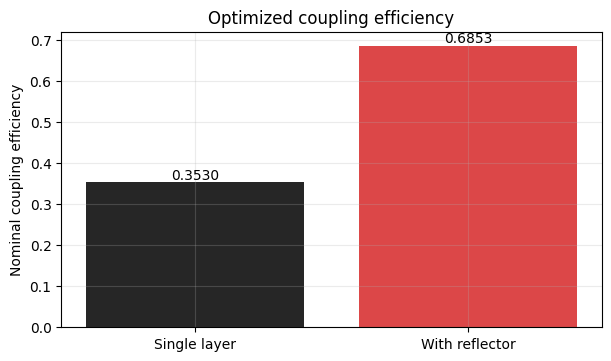

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.5), constrained_layout=True)
ordered_keys = ["single", "reflector"]
x_positions = np.arange(len(ordered_keys))
x_values = [nominal_by_design[key] for key in ordered_keys]
bars = ax.bar(
    x_positions,
    x_values,
    color=[design_colors[key] for key in ordered_keys],
    alpha=0.85,
)
ax.set_xticks(x_positions, [design_labels[key] for key in ordered_keys])
ax.set_ylabel("Nominal coupling efficiency")
ax.set_title("Optimized coupling efficiency")
for bar, value in zip(bars, x_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom",
    )
plt.show()

### Geometry Comparison

The next two plots compare how the optimized devices differ geometrically. The cross sections show the additional lower reflector layer, while the width plot shows how the top grating tooth and gap widths changed in each optimization.

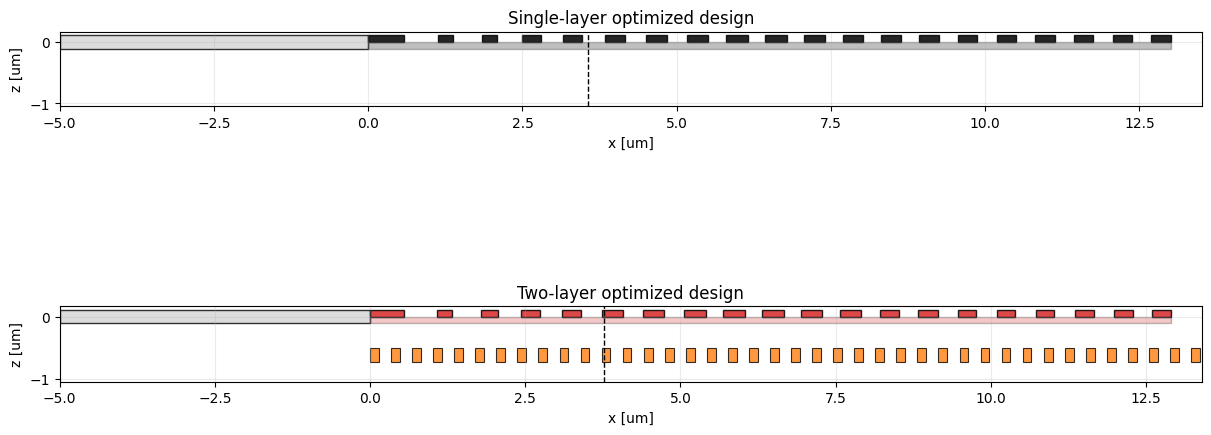

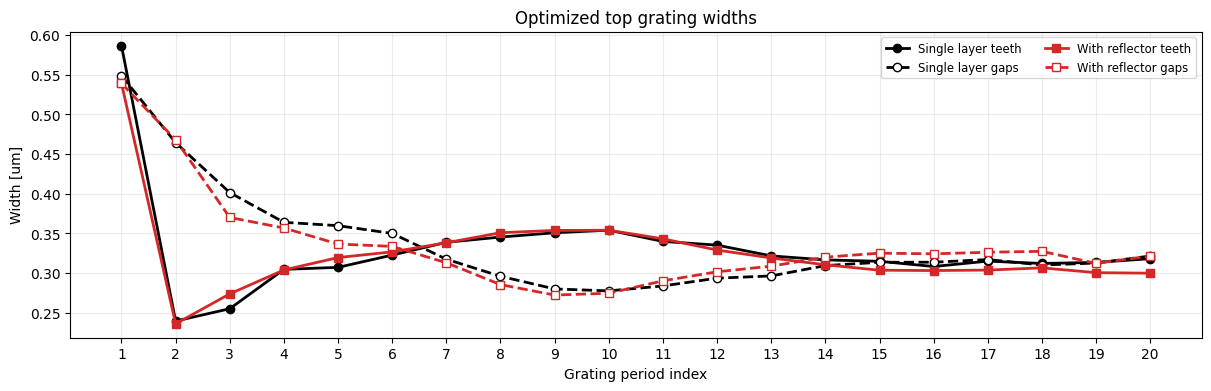

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), constrained_layout=True)
plot_design_cross_section(
    single_design_phys, axes[0], design_colors["single"], "Single-layer optimized design"
)
plot_design_cross_section(
    reflector_design_phys,
    axes[1],
    design_colors["reflector"],
    "Two-layer optimized design",
    include_reflector=True,
)
plt.show()

width_fig = plot_width_comparison(design_params)
plt.show()

### Field Profiles

Finally, we rerun each optimized design with an x-z field monitor. These field plots show how the incident Gaussian beam scatters from the grating region and how the lower reflector changes the field distribution in the two-layer design.

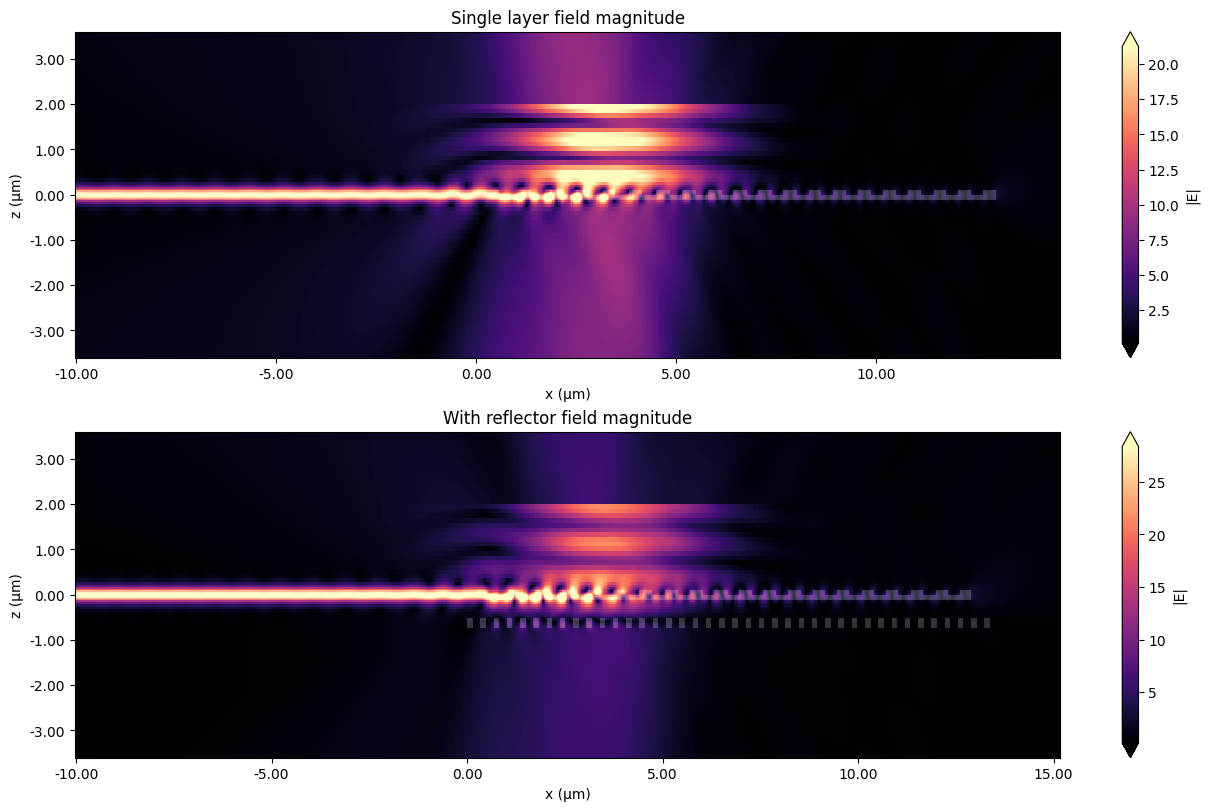

In [17]:
field_data_by_design = {
    "single": field_data_from_sim(
        single_design_phys,
        task_name="grating_beam_single_fields",
        include_reflector=False,
    ),
    "reflector": field_data_from_sim(
        reflector_design_phys,
        task_name="grating_beam_reflector_fields",
        include_reflector=True,
    ),
}
field_fig = plot_field_cross_sections(field_data_by_design)
plt.show()

## Takeaways

This example shows that Gaussian beam source parameters can be treated as first class design variables in a grating coupler optimization, but which parameters are practical to tune depends on the packaging setup. In some systems, the source position or tilt angle may be adjustable during alignment, while the Gaussian waist may be largely fixed by the fiber mode profile or by the packaging optics. In the single-layer case shown here, the optimizer adjusts the grating geometry together with the source position, tilt, and waist to demonstrate the full source parameter optimization workflow.

Adding a lower silicon reflector grating introduces another physically meaningful design handle. The reflector period and duty cycle are optimized jointly with the top grating and source parameters, allowing the lower layer to work with the top grating to redirect more of the incident Gaussian beam into the desired waveguide mode. As the geometry becomes more complex, it becomes even less intuitive where the source should be placed or how it should be tilted, which makes joint optimization of the grating and source parameters an even more powerful technique.